In [1]:
# Code in this notebook is based on tutorial notebook from Detectron2
# Yuxin Wu, Alexander Kirillov, Francisco Massa, Wan-Yen Lo, & Ross Girshick. (2019). Detectron2. .

In [2]:
# CUDA_VISIBLE_DEVICES=""

In [3]:
import sys, os, distutils.core
import torch, detectron2
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

import numpy as np
import os, json, cv2, random
import matplotlib.pyplot as plt 
import json
import matplotlib.image as mpimg

# from google.colab.patches import cv2_imshow

from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog



Matplotlib is building the font cache; this may take a moment.


In [4]:
!nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)
print("detectron2:", detectron2.__version__)

/bin/bash: line 1: nvcc: command not found
torch:  2.4 ; cuda:  cu121
detectron2: 0.6


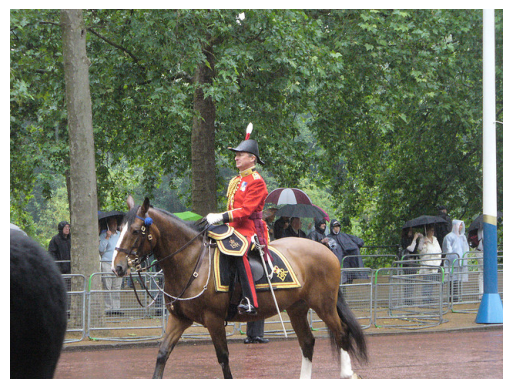

In [5]:
!wget http://images.cocodataset.org/val2017/000000439715.jpg -q -O input.jpg
im = cv2.imread("./input.jpg")
im_rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

plt.imshow(im_rgb)
plt.axis("off")
plt.show()


In [6]:
cfg = get_cfg()
# add project-specific config (e.g., TensorMask) here if you're not running a model in detectron2's core library
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model
# Find a model from detectron2's model zoo. You can use the https://dl.fbaipublicfiles... url as well
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
predictor = DefaultPredictor(cfg)
outputs = predictor(im)

[03/24 14:21:41 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from https://dl.fbaipublicfiles.com/detectron2/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x/137849600/model_final_f10217.pkl ...


/home/gusloryst@GU.GU.SE/d2env/lib/python3.8/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [7]:
# dir(outputs["instances"])
outputs["instances"]._fields.keys()

dict_keys(['pred_boxes', 'scores', 'pred_classes', 'pred_masks'])

In [23]:
# look at the outputs. See https://detectron2.readthedocs.io/tutorials/models.html#model-output-format for specification
print(outputs["instances"].pred_classes)

tensor([17,  0,  0,  0,  0,  0,  0,  0, 25,  0, 25, 25,  0,  0, 24],
       device='cuda:0')


In [30]:
classes = MetadataCatalog.get(cfg.DATASETS.TRAIN[0]).thing_classes
for clss in outputs["instances"].pred_classes:
    print(classes[clss.item()])

horse
person
person
person
person
person
person
person
umbrella
person
umbrella
umbrella
person
person
backpack


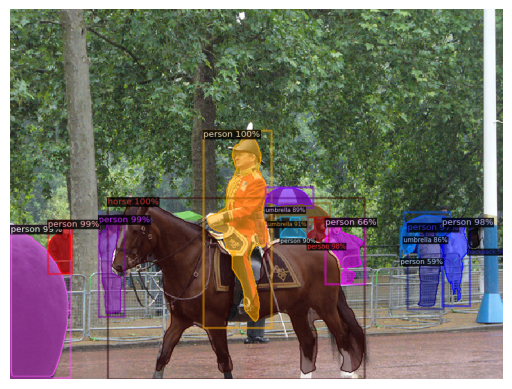

In [9]:
# We can use `Visualizer` to draw the predictions on the image.
v = Visualizer(im_rgb[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

outed = out.get_image()
out_rgb = cv2.cvtColor(outed, cv2.COLOR_BGR2RGB)


plt.imshow(out_rgb)
plt.axis("off")
plt.show()


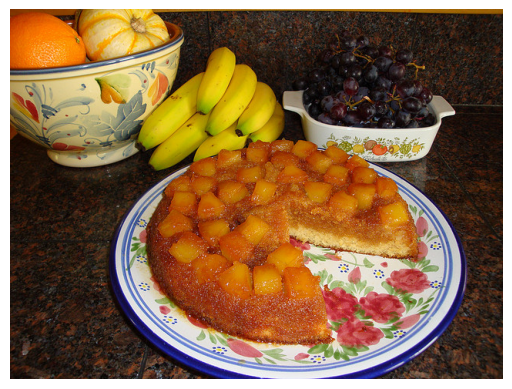

In [10]:
path1 = "./PhotoBook/images/cake_dining_table/COCO_train2014_000000126144.jpg"
path2 = "./PhotoBook/images/cake_dining_table/COCO_train2014_000000134238.jpg"
path3 = "./PhotoBook/images/cake_dining_table/COCO_train2014_000000134599.jpg"
path4 = "./PhotoBook/images/cake_dining_table/COCO_train2014_000000152914.jpg"

example = cv2.imread(path2)
xmpl_rgb = cv2.cvtColor(example, cv2.COLOR_BGR2RGB)

plt.imshow(xmpl_rgb)
plt.axis("off")
plt.show()


In [22]:
exmpl_outputs = predictor(example)
print(exmpl_outputs["instances"].pred_classes)
print(exmpl_outputs["instances"].pred_boxes)

tensor([46, 45, 45, 60, 49, 49, 48, 51, 51], device='cuda:0')
Boxes(tensor([[1.6213e+02, 4.6604e+01, 3.6151e+02, 2.0901e+02],
        [3.5277e+02, 1.0648e+02, 5.8278e+02, 2.0181e+02],
        [0.0000e+00, 3.1134e+00, 2.2304e+02, 2.0560e+02],
        [0.0000e+00, 4.3980e+01, 6.3091e+02, 4.6904e+02],
        [1.0610e+00, 4.9907e+00, 9.5677e+01, 7.9085e+01],
        [8.9783e+01, 4.9006e-01, 2.0903e+02, 6.7071e+01],
        [1.7741e+02, 1.7008e+02, 5.3228e+02, 4.3078e+02],
        [2.7036e+02, 2.6861e+02, 3.4250e+02, 3.3326e+02],
        [2.6867e+02, 3.2917e+02, 3.4668e+02, 3.7400e+02]], device='cuda:0'))


In [19]:
print(exmpl_outputs["instances"]._fields.keys())

dict_keys(['pred_boxes', 'scores', 'pred_classes', 'pred_masks'])


(-0.5, 767.5, 575.5, -0.5)

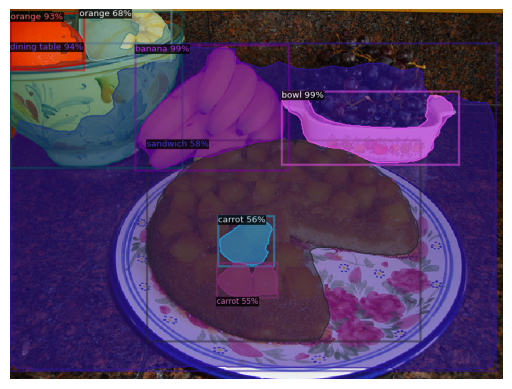

In [12]:
v2 = Visualizer(xmpl_rgb[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)
xmpl_out = v2.draw_instance_predictions(exmpl_outputs["instances"].to("cpu"))
xmpl_outed = xmpl_out.get_image()
xmpl_out_rgb = cv2.cvtColor(xmpl_outed, cv2.COLOR_BGR2RGB)
plt.imshow(xmpl_out_rgb)
plt.axis("off")


In [13]:
# the code below is taken from my file called readData in Photobook folder

In [14]:
with open('PhotoBook/v2/gold-extracted.json', 'r') as file:
    data = json.load(file)
    img_description = {}
    # print(data["person_truck/COCO_train2014_000000258505.jpg"])
    for key in data.keys():
        list_utterances = []
        for subkey in data[key]:
            for dictionary_object in data[key][subkey]:
                list_utterances.append(dictionary_object["Message_Text"])
        img_description[key] = list_utterances


In [15]:
def show_img_descriptions(title, main_dict):
    list_of_keys = list(main_dict.keys())
    if isinstance(title, int):
        title = list_of_keys[title]
    for i, descr in enumerate(main_dict[title]):
        print(i, "-", descr)

    image = mpimg.imread("PhotoBook/images/" + title)
    plt.imshow(image)

# show_img_descriptions(50, img_description)

In [16]:
def compare_dial_Detectron2(title, main_dict):
    list_of_keys = list(main_dict.keys())
    if isinstance(title, int):
        title = list_of_keys[title]
    for i, descr in enumerate(main_dict[title]):
        print(i, "-", descr)

    photo = mpimg.imread("PhotoBook/images/" + title)
    outcome = predictor(photo)

    # predicted_classes = outcome["instances"].pred_classes
    # bounding_boxes = outcome["instances"].pred_boxes
    v3 = Visualizer(photo[:, :, ::-1], MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1.2)

    drawn = v3.draw_instance_predictions(outcome["instances"].to("cpu"))

    visualised = drawn.get_image()
    # out_rgb = cv2.cvtColor(outed, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[1].imshow(photo)
    axes[1].axis('off')

    axes[0].imshow(visualised)
    axes[0].axis('off')
    plt.tight_layout()
    plt.show()

    # plt.imshow(photo)
    # plt.imshow(visualised)

0 - Oriental girl decorating a red umbrella.
1 - Do you have the girl decorating the red umbrella?
2 - What about the girl decorating the red umbrella?


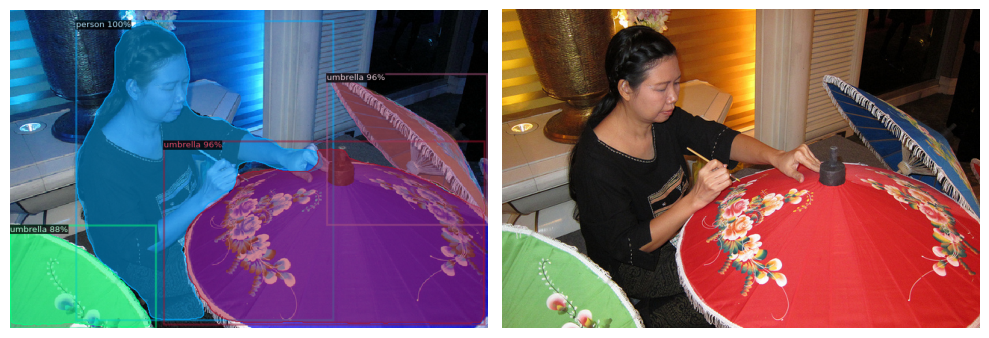

In [17]:
compare_dial_Detectron2(200, img_description)

In [18]:
# Relation detection:
# Tang, K.. (2020). A Scene Graph Generation Codebase in PyTorch.
# Tang, K., Zhang, H., Wu, B., Luo, W., & Liu, W. (2019). Learning to Compose Dynamic Tree Structures for Visual Contexts. In Conference on Computer Vision and Pattern Recognition.
# Tang, K., Niu, Y., Huang, J., Shi, J., & Zhang, H. (2020). Unbiased Scene Graph Generation from Biased Training. In Conference on Computer Vision and Pattern Recognition.

# 

In [37]:
classes = MetadataCatalog.get(cfg.DATASETS.TRAIN[0]).thing_classes

with open('PhotoBook/v2/gold-extracted.json', 'r') as file:
    data = json.load(file)
    file2detected_objects = {}
    for key in data.keys():
        photo = mpimg.imread("PhotoBook/images/" + key)
        outcome = predictor(photo)
        encoded_classes = outcome["instances"].pred_classes
        decoded_classes = [classes[clss.item()] for clss in encoded_classes]
        file2detected_objects[key] = decoded_classes

In [39]:
len(file2detected_objects)

208

In [40]:
%store file2detected_objects

Stored 'file2detected_objects' (dict)


In [41]:
file2detected_objects

{'person_truck/COCO_train2014_000000258505.jpg': ['person',
  'person',
  'person',
  'sports ball',
  'sports ball',
  'car',
  'chair',
  'person',
  'bottle',
  'baseball bat',
  'car',
  'truck'],
 'person_truck/COCO_train2014_000000418229.jpg': ['person',
  'truck',
  'car',
  'bottle',
  'fire hydrant',
  'person'],
 'person_truck/COCO_train2014_000000237372.jpg': ['person',
  'umbrella',
  'car',
  'car',
  'car',
  'car'],
 'person_truck/COCO_train2014_000000227003.jpg': ['person',
  'person',
  'stop sign',
  'truck',
  'backpack'],
 'person_truck/COCO_train2014_000000035995.jpg': ['person',
  'person',
  'person',
  'person',
  'person',
  'tie',
  'person',
  'person',
  'person',
  'person',
  'person',
  'person',
  'tie',
  'person',
  'truck'],
 'person_truck/COCO_train2014_000000099245.jpg': ['person',
  'sports ball',
  'car',
  'car',
  'sports ball',
  'truck',
  'car',
  'handbag',
  'suitcase',
  'sports ball',
  'car'],
 'person_truck/COCO_train2014_000000185945.j